In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [28]:

data = './BTC-market-analysis_2021-25.csv'
df = pd.read_csv(data)
df = df[["date", "btc_return", "sp500_return", "gold_return"]]

In [29]:

df = df.replace(0.000000, pd.NA)
df = df.dropna(subset=["sp500_return"])        
df = df.dropna(subset=["gold_return"])  


In [30]:
df["date"]

1       2021-01-12
2       2021-01-13
3       2021-01-14
4       2021-01-15
8       2021-01-19
           ...    
1820    2026-01-05
1821    2026-01-06
1822    2026-01-07
1823    2026-01-08
1824    2026-01-09
Name: date, Length: 1253, dtype: str

In [31]:

df["BTC Balance"] = 0.00000

df["SP500 Balance"] = 0.00000

df["Gold Balance"] = 0.00000

df["Invested Balance"] = 0.00000

size = len(df)



for i in range(size):  
    if i == 0:
        df.iloc[i,4] = 100
        df.iloc[i,5] = 100
        df.iloc[i,6] = 100
        df.iloc[i,7] = 100
    elif i % 14 == 0:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"]) + 100
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"]) + 100
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"]) + 100
        df.iloc[i,7] = df.iloc[i-1,7] + 100
    else:
        line = df.iloc[i-1]
        df.iloc[i,4] = line["BTC Balance"] * (1 + line["btc_return"])
        df.iloc[i,5] = line["SP500 Balance"] * (1 + line["sp500_return"])
        df.iloc[i,6] = line["Gold Balance"] * (1 + line["gold_return"])
        df.iloc[i,7] = df.iloc[i-1,7]

In [32]:
df['date'] = pd.to_datetime(df['date'])
df['date2'] = df['date']

In [33]:
df.set_index('date2', inplace=True)

In [34]:
# df = df.loc['2021-03':]
np.array(df["date"])

array(['2021-01-12T00:00:00.000000', '2021-01-13T00:00:00.000000',
       '2021-01-14T00:00:00.000000', ..., '2026-01-07T00:00:00.000000',
       '2026-01-08T00:00:00.000000', '2026-01-09T00:00:00.000000'],
      shape=(1253,), dtype='datetime64[us]')

In [35]:
date = np.array(df["date"])
BTC_Balance = np.array(df["BTC Balance"])
SP500_Balance = np.array(df["SP500 Balance"])
Gold_Balance = np.array(df["Gold Balance"])
Invested = np.array(df["Invested Balance"])

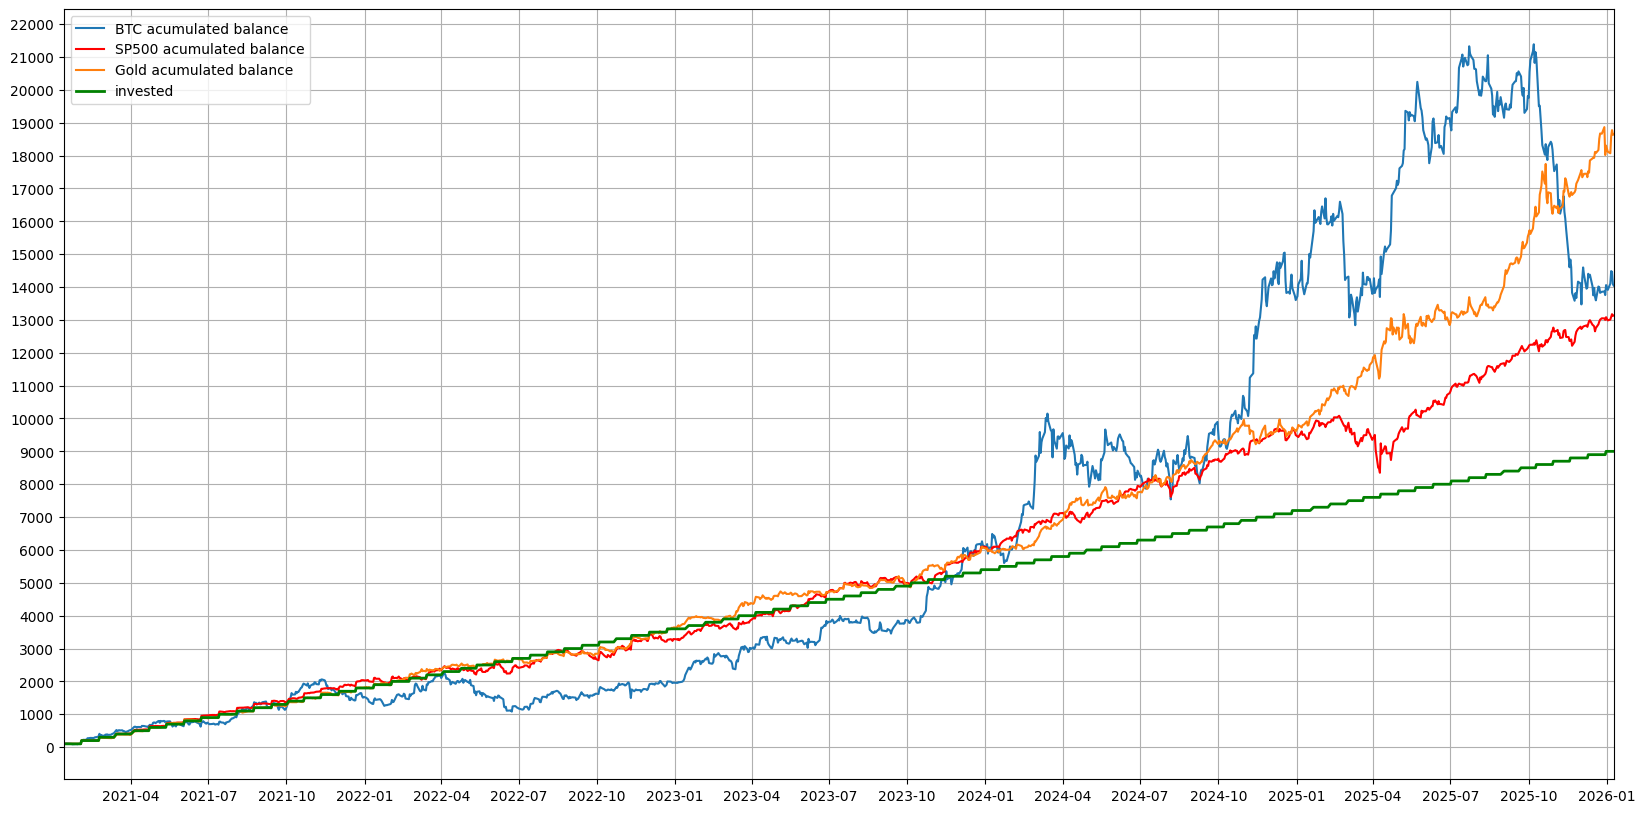

In [36]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(date, BTC_Balance, label='BTC acumulated balance')
ax.plot(date, SP500_Balance, label='SP500 acumulated balance', color = 'red')
ax.plot(date, Gold_Balance, label='Gold acumulated balance')
ax.plot(date, Invested, linewidth=2, label = 'invested', color = 'green')
ax.legend()
ax.yaxis.set_major_locator(ticker.MultipleLocator(1000))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(date[0], date[-1]) 
ax.grid(axis='y')
ax.grid(axis='x')
plt.show()